### Vamos a correr el modelo

Vamos a cargar el modelo Kmeans con K=4 y las alturas del Nb6, y el KNN Imputer de Nb5, estos fueron grabados en modelo_coral_kmeans_k4.pkl en Nb8

Vamos a recibir un archivo CSV con identico formato al recibido originalmente.

| Funciones | Descripción |
| --- | --- |
| procesar_csv_coral | Transformar el archivo CORAL crudo a archivo fecha time 68 ... 159968 |
| preprocesar_para_modelo | Conservar únicamente alturas entre 15000 y 80000 m, eliminar perfiles completamente vacíos y convertir 0s a NaN |
| clasificar_archivo_coral  | Cargar el modelo, ejecutar procesar_csv_coral, preprocesar_para_modelo, imputar faltantes con KNN Imputer, aplicar el modelo e imprimir resultados |
| graficar_evolucion_clusters | Arma un reporte donde se especifican los datos del archivo, la cantidad de perfiles descartados por ser nulos, la cantidad de NaN imputados, y los resultados obtenidos: el cluster dominante, la clasificación de los clusters, su secuencia temporal, y además grafica la evolución temporal y los perfiles térmicos |


In [1]:


import joblib
from pathlib import Path

ruta_modelo = Path(
    r"C:\Users\orlan\Documents\Aprendizaje Automatico\TP\modelo_exportado\modelo_coral_kmeans_k4.pkl"
)

modelo = joblib.load(ruta_modelo)

kmeans = modelo["kmeans"]
knn_imputer = modelo["knn_imputer"]
alturas_modelo = modelo["alturas_modelo"]
metadata = modelo["metadata"]

print("Modelo cargado correctamente")
print(f"Clusters: {kmeans.n_clusters}")
print(f"Alturas: {len(alturas_modelo)}")
print(f"Primera altura: {alturas_modelo[0]}")
print(f"Última altura: {alturas_modelo[-1]}")

Modelo cargado correctamente
Clusters: 4
Alturas: 650
Primera altura: 15068
Última altura: 79968


In [2]:
# Vamos a empezar armando una función que transforme el archivo CORAL crudo al formato que usamos en el modelo
# Una fila, un perfil, y una columna, una altura.
# Además, nombre del archivo, fecha y time.

from pathlib import Path
import pandas as pd


def procesar_csv_coral(archivo_csv):
    archivo = Path(archivo_csv)

    # Leer CSV
    df = pd.read_csv(archivo)

    # Limpiar nombres de columnas
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
    )

    # Verificar columnas requeridas
    columnas_requeridas = [
        "time",
        "altitude",
        "temperature"
    ]

    faltantes = [
        c for c in columnas_requeridas
        if c not in df.columns
    ]

    if faltantes:
        raise ValueError(
            f"Faltan columnas en {archivo.name}: {faltantes}. "
            f"Columnas encontradas: {list(df.columns)}"
        )

    # Conservar columnas necesarias
    df = df[
        ["time", "altitude", "temperature"]
    ]

    # Pivotear: una fila por perfil, una columna por altura
    df_pivot = (
        df.pivot(
            index="time",
            columns="altitude",
            values="temperature"
        )
        .reset_index()
    )

     # Quita el nombre del eje de columnas
    df_pivot.columns.name = None
    
    # Nombre del archivo
    nombre = archivo.stem

    # Fecha desde el nombre YYYYMMDD
    fecha = pd.to_datetime(
        nombre[:8],
        format="%Y%m%d"
    ).date()

    # Insertar columnas identificatorias
    df_pivot.insert(0, "archivo", nombre)
    df_pivot.insert(1, "fecha", fecha)

    # Ordenar columnas
    cols_fijas = ["archivo", "fecha", "time"]

    cols_altura = sorted(
        [c for c in df_pivot.columns if c not in cols_fijas]
    )

    df_pivot = df_pivot[
        cols_fijas + cols_altura
    ]

    return df_pivot

In [3]:
# Vamos a armar armar una función que conserve únicamente alturas entre 15000 y 80000 m, eliminar perfiles completamente vacíos y convertir 0s a NaN

import numpy as np

def preprocesar_para_modelo(df_perfiles, alturas_modelo):
    df_trabajo = df_perfiles.copy()

    cols_fijas = ["archivo", "fecha", "time"]

    df_trabajo.columns = [
        str(c) if c not in cols_fijas else c
        for c in df_trabajo.columns
    ]

    alturas_modelo = [str(c) for c in alturas_modelo]

    cols_altura = [
        c for c in df_trabajo.columns
        if c not in cols_fijas
    ]

    cols_altura_rango = [
        c for c in cols_altura
        if 15000 <= int(c) <= 80000
    ]

    perfiles_originales = len(df_trabajo)

    df_trabajo = df_trabajo[
        cols_fijas + cols_altura_rango
    ].copy()

    datos_altura = df_trabajo[cols_altura_rango]

    mascara_perfil_valido = ~(
        datos_altura.fillna(0).eq(0).all(axis=1)
    )

    perfiles_descartados = (~mascara_perfil_valido).sum()

    df_trabajo = df_trabajo[mascara_perfil_valido].copy()

    df_trabajo[cols_altura_rango] = (
        df_trabajo[cols_altura_rango]
        .replace(0, np.nan)
    )

    alturas_agregadas = []

    for altura in alturas_modelo:
        if altura not in df_trabajo.columns:
            df_trabajo[altura] = np.nan
            alturas_agregadas.append(altura)

    df_modelo = df_trabajo[
        cols_fijas + alturas_modelo
    ].copy()

    X_modelo = df_modelo[alturas_modelo].copy()

    X_modelo = X_modelo.astype(float)

    resumen_preprocesamiento = {
        "perfiles_originales": perfiles_originales,
        "perfiles_descartados": int(perfiles_descartados),
        "perfiles_validos": len(df_modelo),
        "alturas_en_rango_archivo": len(cols_altura_rango),
        "alturas_modelo": len(alturas_modelo),
        "alturas_agregadas_por_faltantes": len(alturas_agregadas)
    }

    return df_modelo, X_modelo, resumen_preprocesamiento

In [4]:
# Vamos a armar armar una función que clasifique el archivo, va a hacer lo siguiente:
# cargar el modelo, ejecutar procesar_csv_coral, preprocesar_para_modelo, imputar faltantes con KNN Imputer, aplicar el modelo e imprimir resultados


def clasificar_archivo_coral(archivo_csv, modelo):
    # Extraer objetos del modelo
    kmeans = modelo["kmeans"]
    knn_imputer = modelo["knn_imputer"]
    alturas_modelo = modelo["alturas_modelo"]

    # 1. Procesar CSV CORAL crudo
    df_perfiles = procesar_csv_coral(archivo_csv)

    # 2. Preprocesar para el modelo
    df_modelo, X_modelo, resumen_preprocesamiento = preprocesar_para_modelo(
        df_perfiles,
        alturas_modelo
    )

    # 3. Imputar faltantes
    X_imputado = knn_imputer.transform(X_modelo)

    X_imputado = pd.DataFrame(
        X_imputado,
        columns=alturas_modelo,
        index=X_modelo.index
    )

    # 4. Clasificar perfiles
    clusters = kmeans.predict(X_imputado)

    # 5. Armar resultado por perfil
    df_resultado = df_modelo.copy()
    df_resultado["cluster"] = clusters

    # 6. Resumen de clusters
    resumen_clusters = (
        df_resultado["cluster"]
        .value_counts()
        .sort_index()
        .rename_axis("cluster")
        .reset_index(name="cantidad")
    )

    resumen_clusters["porcentaje"] = (
        resumen_clusters["cantidad"] /
        resumen_clusters["cantidad"].sum() * 100
    ).round(2)

    return df_resultado, resumen_preprocesamiento, resumen_clusters, X_modelo, X_imputado


In [21]:
# Vamos a armar armar una función para armar un reporte donde se especifica lo siguiente:
# los datos del archivo, la cantidad de perfiles descartados por ser totalmente nulos, la cantidad de NaN imputados
# los resultados obtenidos: el cluster dominante, la clasificación de los clusters, su secuencia temporal
# y además grafica la evolución temporal y los perfiles térmicos

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import textwrap


def graficar_reporte_noche_coral(
    df_resultado,
    X_modelo,
    X_imputado,
    resumen_preprocesamiento,
    guardar_como=None,
    ancho_secuencia=38
):
    """
    Genera un reporte gráfico completo para una noche CORAL clasificada.

    Incluye:
    - Resumen del archivo.
    - Distribución de clusters.
    - Evolución temporal de clusters.
    - Perfiles térmicos coloreados por cluster.
    - Tramos imputados diferenciados con línea punteada.
    - Guardado automático del reporte en PNG.

    Parámetros
    ----------
    df_resultado : DataFrame
        DataFrame con columnas archivo, fecha, time y cluster.

    X_modelo : DataFrame
        Matriz antes de imputar, con NaN en valores faltantes.

    X_imputado : DataFrame o ndarray
        Matriz después de imputar, usada por el modelo.

    resumen_preprocesamiento : dict
        Diccionario devuelto por preprocesar_para_modelo().

    guardar_como : str, Path o None
        Ruta opcional para guardar la figura.
        Si es None, guarda automáticamente en reportes_modelo/reporte_FECHA.png.

    ancho_secuencia : int
        Ancho máximo de línea para la secuencia temporal.
    """

    # ============================================================
    # Preparación
    # ============================================================

    colores = {
        0: "#0072B2",  # azul
        1: "#009E73",  # verde azulado
        2: "#CC79A7",  # violeta
        3: "#D55E00"   # naranja oscuro
    }

    # Asegurar que X_imputado sea DataFrame
    if not isinstance(X_imputado, pd.DataFrame):
        X_imputado = pd.DataFrame(
            X_imputado,
            columns=X_modelo.columns,
            index=X_modelo.index
        )

    df_plot = (
        df_resultado
        .sort_values("time")
        .reset_index(drop=False)
        .rename(columns={"index": "idx_original"})
    )

    alturas_km = X_modelo.columns.astype(float) / 1000

    archivo = df_resultado["archivo"].iloc[0]
    fecha = df_resultado["fecha"].iloc[0]

    n_originales = resumen_preprocesamiento["perfiles_originales"]
    n_validos = resumen_preprocesamiento["perfiles_validos"]
    n_descartados = resumen_preprocesamiento["perfiles_descartados"]

    rango_min = alturas_km.min()
    rango_max = alturas_km.max()

    imputados_por_perfil = X_modelo.isna().sum(axis=1)

    imp_min = imputados_por_perfil.min()
    imp_med = imputados_por_perfil.mean()
    imp_max = imputados_por_perfil.max()

    conteos = (
        df_resultado["cluster"]
        .value_counts()
        .sort_index()
    )

    total = len(df_resultado)

    if total > 0:
        dominante = conteos.idxmax()
    else:
        dominante = None

    # Secuencia temporal con salto automático de línea
    secuencia_completa = " → ".join(
        f"C{c}"
        for c in df_plot["cluster"]
    )

    secuencia = "\n".join(
        textwrap.wrap(
            secuencia_completa,
            width=ancho_secuencia,
            break_long_words=False,
            break_on_hyphens=False
        )
    )

    # ============================================================
    # Figura general
    # ============================================================

    fig = plt.figure(figsize=(15, 12))

    gs = fig.add_gridspec(
        nrows=3,
        ncols=2,
        height_ratios=[1.25, 1.0, 4],
        hspace=0.45,
        wspace=0.25
    )

    ax_info = fig.add_subplot(gs[0, 0])
    ax_clas = fig.add_subplot(gs[0, 1])
    ax_clusters = fig.add_subplot(gs[1, :])
    ax_perfiles = fig.add_subplot(gs[2, :])

    # ============================================================
    # Panel 1: Resumen del archivo
    # ============================================================

    texto_info = (
        f"Archivo:\n"
        f"{archivo}\n\n"
        f"Fecha: {fecha}\n\n"
        f"Perfiles originales : {n_originales}\n"
        f"Perfiles válidos    : {n_validos}\n"
        f"Perfiles descartados: {n_descartados}\n\n"
        f"Rango vertical:\n"
        f"{rango_min:.1f} - {rango_max:.1f} km\n\n"
        f"Imputación por perfil:\n"
        f"mín={imp_min} | media={imp_med:.1f} | máx={imp_max}"
    )

    ax_info.text(
        0.02,
        0.98,
        texto_info,
        va="top",
        ha="left",
        family="monospace",
        fontsize=10
    )

    ax_info.set_title("Resumen del archivo")
    ax_info.axis("off")

    # ============================================================
    # Panel 2: Clasificación
    # ============================================================

    lineas_clusters = []

    for cluster in [0, 1, 2, 3]:
        cantidad = conteos.get(cluster, 0)
        porcentaje = 100 * cantidad / total if total > 0 else 0

        lineas_clusters.append(
            f"C{cluster}: {cantidad:2d} perfiles ({porcentaje:5.1f}%)"
        )

    texto_clas = (
        "\n".join(lineas_clusters)
        + "\n\n"
        + f"Cluster dominante:\n"
        + (f"C{dominante}" if dominante is not None else "Sin perfiles")
        + "\n\n"
        + "Secuencia temporal:\n"
        + secuencia
    )

    ax_clas.text(
        0.02,
        0.98,
        texto_clas,
        va="top",
        ha="left",
        family="monospace",
        fontsize=10
    )

    ax_clas.set_title("Clasificación")
    ax_clas.axis("off")

    # ============================================================
    # Panel 3: Evolución temporal de clusters
    # ============================================================

    ax_clusters.step(
        range(len(df_plot)),
        df_plot["cluster"],
        where="mid",
        linewidth=2,
        color="black"
    )

    for i, fila in df_plot.iterrows():
        cluster = fila["cluster"]

        ax_clusters.scatter(
            i,
            cluster,
            s=80,
            color=colores[cluster],
            zorder=3
        )

    ax_clusters.set_yticks([0, 1, 2, 3])
    ax_clusters.set_yticklabels(["C0", "C1", "C2", "C3"])

    ax_clusters.set_xlabel("Perfil dentro de la noche")
    ax_clusters.set_ylabel("Cluster")
    ax_clusters.set_title("Evolución temporal de clusters")
    ax_clusters.grid(alpha=0.3)

    # ============================================================
    # Panel 4: Perfiles térmicos
    # ============================================================

    for _, fila in df_plot.iterrows():
        idx = fila["idx_original"]
        cluster = fila["cluster"]

        perfil_original = X_modelo.loc[idx]
        perfil_imputado = X_imputado.loc[idx]

        mascara_observado = ~perfil_original.isna()
        mascara_imputado = perfil_original.isna()

        # Perfil completo imputado, como referencia suave
        ax_perfiles.plot(
            perfil_imputado,
            alturas_km,
            color=colores[cluster],
            alpha=0.25,
            linewidth=1.0
        )

        # Tramos observados
        perfil_observado = perfil_imputado.copy()
        perfil_observado[~mascara_observado] = np.nan

        ax_perfiles.plot(
            perfil_observado,
            alturas_km,
            color=colores[cluster],
            alpha=0.9,
            linewidth=1.6
        )

        # Tramos imputados
        perfil_imp = perfil_imputado.copy()
        perfil_imp[~mascara_imputado] = np.nan

        ax_perfiles.plot(
            perfil_imp,
            alturas_km,
            color=colores[cluster],
            alpha=0.9,
            linewidth=2.4,
            linestyle=":"
        )

    ax_perfiles.set_xlabel("Temperatura (K)")
    ax_perfiles.set_ylabel("Altura (km)")
    ax_perfiles.set_title("Perfiles térmicos clasificados por cluster")
    ax_perfiles.grid(alpha=0.3)

    # ============================================================
    # Leyenda
    # ============================================================

    elementos_leyenda = []

    for cluster in [0, 1, 2, 3]:
        cantidad = conteos.get(cluster, 0)
        porcentaje = 100 * cantidad / total if total > 0 else 0

        elementos_leyenda.append(
            Line2D(
                [0], [0],
                color=colores[cluster],
                lw=2,
                label=f"C{cluster} ({cantidad}, {porcentaje:.1f}%)"
            )
        )

    elementos_leyenda.append(
        Line2D(
            [0], [0],
            color="black",
            lw=2.5,
            linestyle=":",
            label="Tramo imputado"
        )
    )

    ax_perfiles.legend(
        handles=elementos_leyenda,
        loc="best"
    )

    # ============================================================
    # Cierre y guardado
    # ============================================================

    fig.suptitle(
        "Reporte de clasificación automática de noche CORAL",
        fontsize=14,
        y=0.97
    )

    carpeta_reportes = Path("reportes_modelo")
    carpeta_reportes.mkdir(exist_ok=True)

    if guardar_como is None:
        fecha_archivo = pd.to_datetime(fecha).strftime("%Y%m%d")
        guardar_como = carpeta_reportes / f"reporte_{fecha_archivo}.png"
    else:
        guardar_como = Path(guardar_como)

    plt.savefig(
        guardar_como,
        dpi=300,
        bbox_inches="tight"
    )

    print(f"Reporte guardado en: {guardar_como.resolve()}")

    plt.show()

Reporte guardado en: C:\Users\orlan\Documents\Aprendizaje Automatico\TP\reportes_modelo\reporte_20230621.png


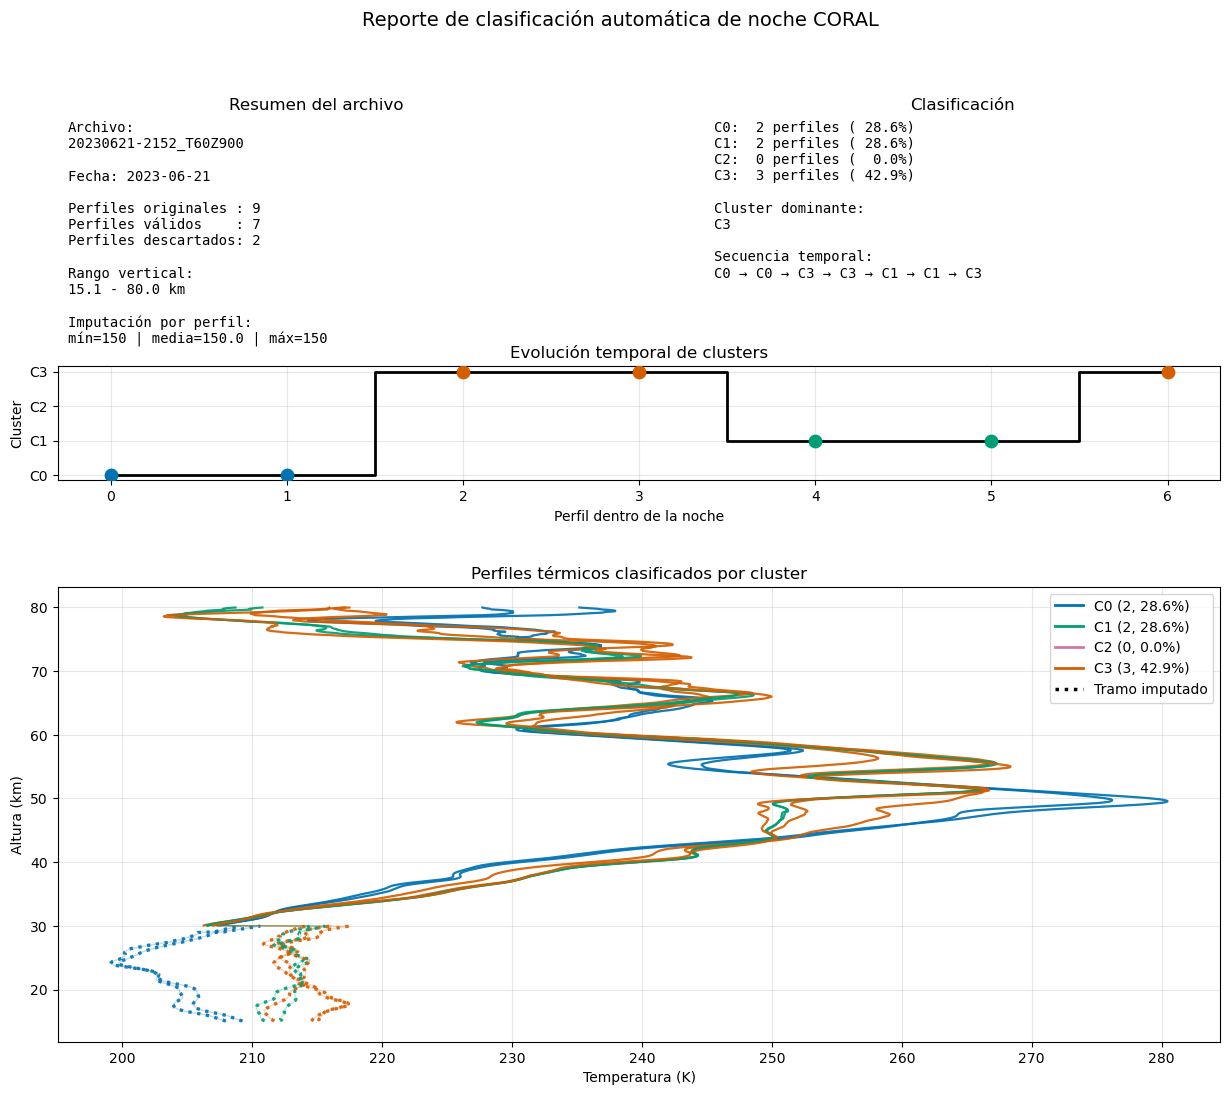

In [23]:
# Vamos a ejecutar el conjunto

archivo_csv = r"C:\Users\orlan\OneDrive\Documents\Tecnicatura\2A1C - Aprendizaje Automatico\Estacion Astronomica RG - Lidar GW\data\data\20230621-2152_T60Z900.csv"

df_resultado, resumen_preprocesamiento, resumen_clusters, X_modelo, X_imputado = clasificar_archivo_coral(
    archivo_csv,
    modelo)

resumen_preprocesamiento
graficar_reporte_noche_coral(
    df_resultado,
    X_modelo,
    X_imputado,
    resumen_preprocesamiento,
    ancho_secuencia = 32
)

